# Zomato Restaurant Rating Prediction
## Machine Learning Project — CDAC
**Version: With Imputation**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re
import pickle
import warnings

from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')

In [2]:
# Load the dataset — update the path as per your setup
df = pd.read_csv('/Users/huntstar/Projects/Zomato_project/Data/zomato.csv')

print(f"Retrieved {len(df)} rows from dataset!")
df.head()

Retrieved 51717 rows from dataset!


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [3]:
df.shape

(51717, 17)

In [4]:
df['dish_liked']

0        Pasta, Lunch Buffet, Masala Papad, Paneer Laja...
1        Momos, Lunch Buffet, Chocolate Nirvana, Thai G...
2        Churros, Cannelloni, Minestrone Soup, Hot Choc...
3                                              Masala Dosa
4                                      Panipuri, Gol Gappe
                               ...                        
51712                                                  NaN
51713                                                  NaN
51714                                                  NaN
51715                         Cocktails, Pizza, Buttermilk
51716                                                  NaN
Name: dish_liked, Length: 51717, dtype: str

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   rest_type                    51490 non-null  str  
 10  dish_liked                   23639 non-null  str  
 11  cuisines                     51672 non-null  str  
 12  approx_cost(for two people)  51371 non-null  str  
 13  reviews_list                 51717 non-null  str  
 14  m

In [6]:
# Drop columns that aren't useful for general ML models
cols_to_drop = ['url', 'address', 'phone']
df = df.drop(columns=cols_to_drop)

In [7]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [8]:
df.isna().sum()

name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [9]:
df.shape

(51717, 14)

In [10]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(51654, 14)

In [12]:
def clean_rate(value):
    if value == 'NEW' or value == '-' or str(value) == 'None':
        return np.nan
    else:
        value = str(value).split('/')[0]
        try:
            return float(value)
        except ValueError:
            return np.nan

In [13]:
df['rate'] = df['rate'].apply(clean_rate)
df['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, nan, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

In [14]:
def extract_all_reviews_mean(review_list_str):
    """
    Parses reviews_list, extracts EVERY rating present in the list,
    and calculates the overall mean of all ratings for that restaurant.
    """
    if pd.isna(review_list_str) or not isinstance(review_list_str, str):
        return np.nan

    try:
        reviews = ast.literal_eval(review_list_str)
        all_ratings = []

        for rev in reviews:
            match = re.search(r'Rated\s*(\d+\.?\d*)', str(rev))
            if match:
                rating_val = float(match.group(1))
                if 1.0 <= rating_val <= 5.0:
                    all_ratings.append(rating_val)

        return np.mean(all_ratings) if all_ratings else np.nan
    except Exception:
        return np.nan

In [15]:
# Fill missing 'rate' from reviews_list
missing_rate_mask = df['rate'].isna()
df.loc[missing_rate_mask, 'rate'] = df.loc[missing_rate_mask, 'reviews_list'].apply(extract_all_reviews_mean)

# Fill any remaining NaN in 'rate' with the overall mean
if df['rate'].isna().any():
    overall_mean_rate = df['rate'].mean()
    df['rate'] = df['rate'].fillna(overall_mean_rate)

# Round to 1 decimal place
df['rate'] = df['rate'].round(1)

print("Filled missing rate values using the mean of ALL reviews in reviews_list and overall mean!")
print(df[['rate', 'reviews_list']].isna().sum())

Filled missing rate values using the mean of ALL reviews in reviews_list and overall mean!
rate            0
reviews_list    0
dtype: int64


In [16]:
df.isna().sum()

name                               0
online_order                       0
book_table                         0
rate                               0
votes                              0
location                          21
rest_type                        227
dish_liked                     28027
cuisines                          45
approx_cost(for two people)      345
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [17]:
(df['votes'] == 0).sum()

np.int64(10002)

In [18]:
df['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, 4.5, 2.9, 3.5, 1. , 2.6, 3.4, 5. , 2.5, 2.7, 2. , 4.7,
       4.8, 1.8, 2.4, 2.2, 2.3, 4.9, 1.5, 2.1, 1.3, 1.4, 1.2, 1.6, 1.9,
       1.7])

In [19]:
# Chi-Square Test to justify Grouped Mode Imputation for rest_type
contingency_table = pd.crosstab(df['listed_in(type)'], df['rest_type'])

chi2_stat, p_val, dof, expected_freq = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"p-value: {p_val:.4e}")
print(f"Degrees of Freedom: {dof}")

alpha = 0.05
if p_val < alpha:
    print("\nResult: Reject Null Hypothesis (H0).")
    print("Statistically significant dependency exists between 'listed_in(type)' and 'rest_type'.")
    print("--> Proceeding with Grouped Mode Imputation is statistically justified!")
else:
    print("\nResult: Fail to reject Null Hypothesis (H0).")
    print("No significant relationship found between the variables.")

Chi-Square Statistic: 62835.2225
p-value: 0.0000e+00
Degrees of Freedom: 552

Result: Reject Null Hypothesis (H0).
Statistically significant dependency exists between 'listed_in(type)' and 'rest_type'.
--> Proceeding with Grouped Mode Imputation is statistically justified!


In [20]:
# Grouped Mode Imputation based on Chi-Square dependency
mode_by_type = df.groupby('listed_in(type)')['rest_type'].transform(
    lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'
)
print(mode_by_type.unique())

<StringArray>
[     'Casual Dining',               'Cafe',        'Quick Bites',
     'Dessert Parlor',                'Bar', 'Casual Dining, Bar']
Length: 6, dtype: str


In [21]:
df['rest_type'] = df['rest_type'].fillna(mode_by_type)

In [22]:
def assign_sentiment(rate):
    if rate < 3.0:
        return 'Bad'
    elif rate < 4.0:
        return 'Good'
    else:
        return 'Excellent'

df['sentiment'] = df['rate'].apply(assign_sentiment)

print("Sentiment column created based on rating thresholds (Bad < 3, Good 3-4, Excellent >= 4).")
display(df[['name', 'rate', 'sentiment']].head())

Sentiment column created based on rating thresholds (Bad < 3, Good 3-4, Excellent >= 4).


,name,rate,sentiment
0,Jalsa,4.1,Excellent
1,Spice Elephant,4.1,Excellent
2,San Churro Cafe,3.8,Good
3,Addhuri Udupi Bhojana,3.7,Good
4,Grand Village,3.8,Good


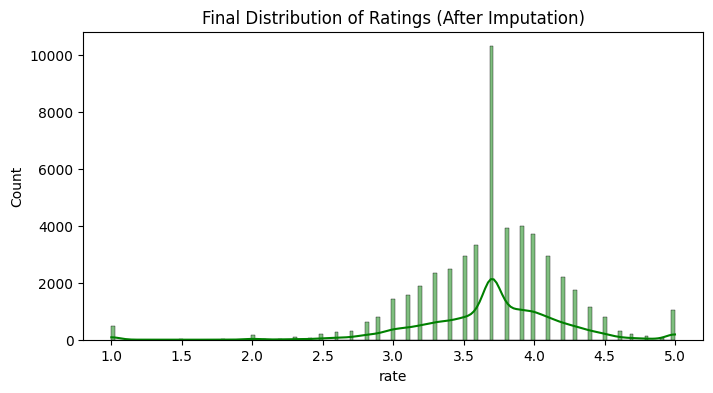

Correlation between Votes and Rate: 0.3203


In [23]:
# Visualizing the final distribution of the 'rate' column
plt.figure(figsize=(8, 4))
sns.histplot(df['rate'], kde=True, color='green')
plt.title('Final Distribution of Ratings (After Imputation)')
plt.show()

# Correlation between votes and rate
correlation = df[['votes', 'rate']].corr().iloc[0, 1]
print(f"Correlation between Votes and Rate: {correlation:.4f}")

In [24]:
df.shape

(51654, 15)

In [25]:
# Clean 'approx_cost(for two people)'
def clean_cost(value):
    value = str(value).strip()
    if value == 'None' or value == '' or value == 'nan':
        return np.nan
    if ',' in value:
        value = value.replace(',', '')
    try:
        return float(value)
    except ValueError:
        return np.nan

In [26]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].apply(clean_cost)
print("Cost column cleaned successfully!")
print(df['approx_cost(for two people)'].unique()[:10])

Cost column cleaned successfully!
[800. 300. 600. 700. 550. 500. 450. 650. 400. 900.]


In [27]:
# Fill missing approx_cost with median
cost_median = df['approx_cost(for two people)'].median()
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].fillna(cost_median)
print(f"Missing approx_cost filled with median: {cost_median}")

Missing approx_cost filled with median: 400.0


In [28]:
df.info()

<class 'pandas.DataFrame'>
Index: 51654 entries, 0 to 51716
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         51654 non-null  str    
 1   online_order                 51654 non-null  str    
 2   book_table                   51654 non-null  str    
 3   rate                         51654 non-null  float64
 4   votes                        51654 non-null  int64  
 5   location                     51633 non-null  str    
 6   rest_type                    51654 non-null  str    
 7   dish_liked                   23627 non-null  str    
 8   cuisines                     51609 non-null  str    
 9   approx_cost(for two people)  51654 non-null  float64
 10  reviews_list                 51654 non-null  str    
 11  menu_item                    51654 non-null  str    
 12  listed_in(type)              51654 non-null  str    
 13  listed_in(city)              516

In [29]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)',
       'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)',
       'sentiment'],
      dtype='str')

In [30]:
df.isna().sum()

name                               0
online_order                       0
book_table                         0
rate                               0
votes                              0
location                          21
rest_type                          0
dish_liked                     28027
cuisines                          45
approx_cost(for two people)        0
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
sentiment                          0
dtype: int64

## Feature Engineering & Encoding

In [31]:
# Binary encoding for online_order and book_table
for col in ['online_order', 'book_table']:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0}).fillna(0)

# Label encoding for categorical columns
categorical_cols = ['location', 'rest_type', 'listed_in(type)']
for col in categorical_cols:
    if col in df.columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Select features for Supervised Learning
# features = ['online_order', 'book_table', 'votes', 'location']
features = ['online_order', 'book_table', 'votes', 'location', 'approx_cost(for two people)']
X = df[features]
y_reg = df['rate']

In [32]:
# Binary classification target (1 = High Rating >= 3.8, 0 = Low Rating)
y_cls = (df['rate'] >= 3.8).astype(int)

# Split for classification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_cls, test_size=0.2, random_state=42)

print("Classification target and splits defined successfully.")
print(f"Target distribution:\n{y_cls.value_counts(normalize=True)}")

Classification target and splits defined successfully.
Target distribution:
rate
0    0.569249
1    0.430751
Name: proportion, dtype: float64


## 1. Decision Tree — Regression
Predict the exact restaurant rating (continuous value).

In [33]:
# Split for regression
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

print(f"Training set : {X_train.shape}")
print(f"Testing set  : {X_test.shape}")

Training set : (41323, 5)
Testing set  : (10331, 5)


In [34]:
# # Train Decision Tree Regressor
# dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
# dt_reg.fit(X_train, y_train)

# print("Decision Tree Regressor trained successfully!")
# print(f"Tree Depth : {dt_reg.get_depth()}")
# print(f"Leaves     : {dt_reg.get_n_leaves()}")

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# Define the parameter grid
param_grid_reg = {
    'max_depth': [3, 5, 7, 10, None],           # None means no limit
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None]      # for regression, 'auto' is same as None
}

# Create base model
dt_reg = DecisionTreeRegressor(random_state=42)

# Grid search with 5-fold cross-validation
grid_reg = GridSearchCV(
    estimator=dt_reg,
    param_grid=param_grid_reg,
    cv=5,
    scoring='r2',              # optimize R² for regression
    n_jobs=-1,                 # use all CPU cores
    verbose=1                  # show progress
)

# Fit on training data
grid_reg.fit(X_train, y_train)

# Best model
best_dt_reg = grid_reg.best_estimator_

print("Best Parameters for Regressor:", grid_reg.best_params_)
print("Best Cross-Validation R²:", grid_reg.best_score_)

# (Optional) Use best model for predictions
y_pred_reg = best_dt_reg.predict(X_test)

# Evaluate as before
mae  = mean_absolute_error(y_test, y_pred_reg)
mse  = mean_squared_error(y_test, y_pred_reg)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_reg)

print("\n--- Tuned Decision Tree Regressor Results ---")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Best Parameters for Regressor: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation R²: 0.5379925393892666

--- Tuned Decision Tree Regressor Results ---
MAE  : 0.1179
MSE  : 0.1129
RMSE : 0.3360
R²   : 0.6064


In [36]:
# # Predictions
# y_pred_reg = dt_reg.predict(X_test)

# # Evaluation Metrics
# mae  = mean_absolute_error(y_test, y_pred_reg)
# mse  = mean_squared_error(y_test, y_pred_reg)
# rmse = np.sqrt(mse)
# r2   = r2_score(y_test, y_pred_reg)

# print("--- Decision Tree Regressor Results ---")
# print(f"MAE  : {mae:.4f}")
# print(f"MSE  : {mse:.4f}")
# print(f"RMSE : {rmse:.4f}")
# print(f"R²   : {r2:.4f}")

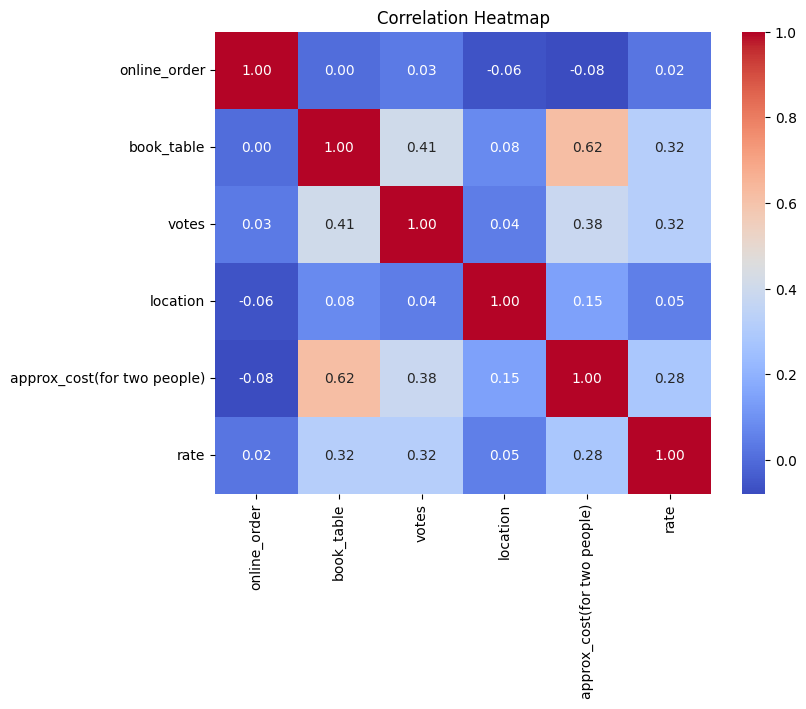

In [37]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[features + ['rate']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

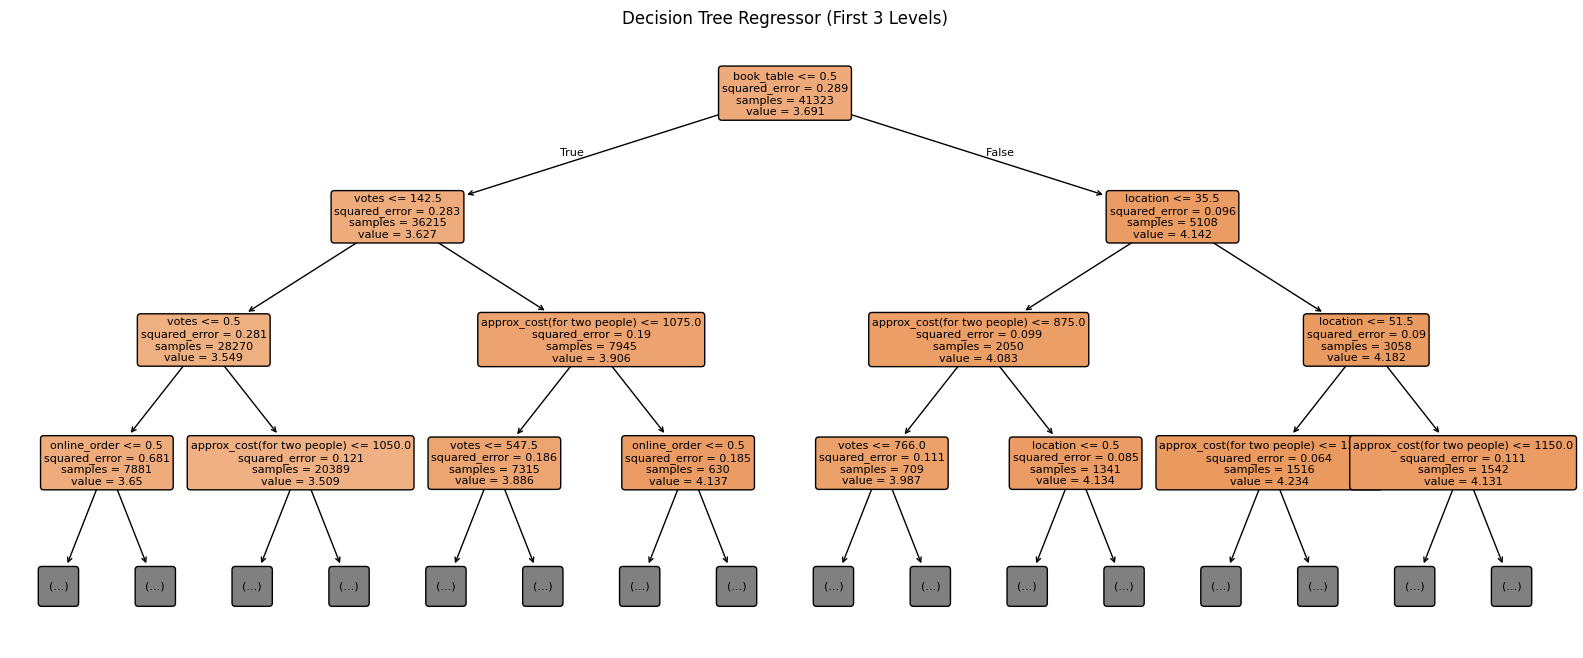

In [38]:
# Visualize Decision Tree Regressor
plt.figure(figsize=(20, 8))
plot_tree(
    best_dt_reg,
    feature_names=features,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title("Decision Tree Regressor (First 3 Levels)")
plt.show()

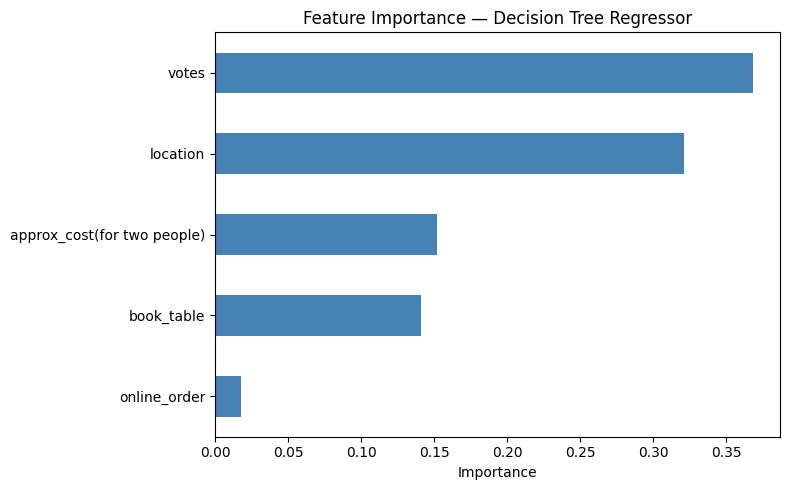

In [39]:
# Feature Importance — Regressor
importances_reg = pd.Series(best_dt_reg.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances_reg.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Decision Tree Regressor')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [40]:
from sklearn.model_selection import cross_val_score

# For regression (using R²)
cv_scores_reg = cross_val_score(best_dt_reg, X_train, y_train, cv=5, scoring='r2')
print(f"Cross-Validation R²: {cv_scores_reg.mean():.4f} (+/- {cv_scores_reg.std():.4f})")

Cross-Validation R²: 0.5380 (+/- 0.0267)


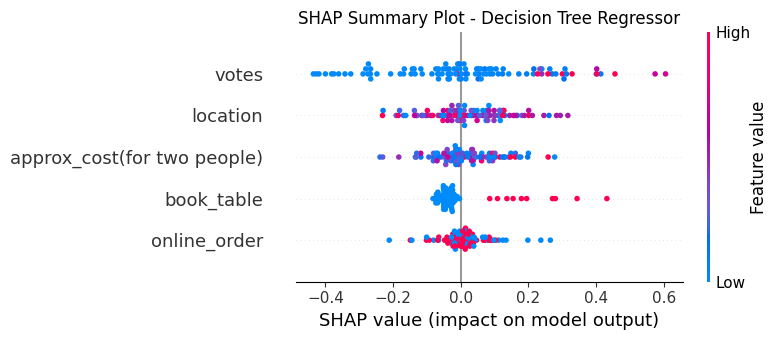

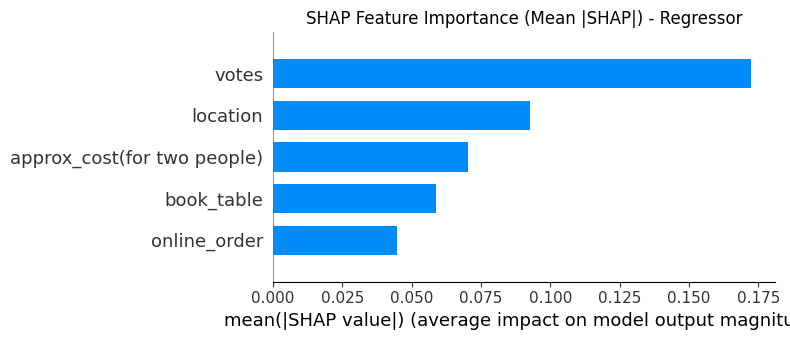

In [41]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# ----- For Regression -----
# Use a subset of the test set for faster computation (optional)
X_test_sample = X_test.sample(n=100, random_state=42)  # Use 100 samples for speed

# Create a TreeExplainer for the regressor
explainer_reg = shap.TreeExplainer(best_dt_reg)
shap_values_reg = explainer_reg.shap_values(X_test_sample)

# Summary plot - shows feature importance and impact direction
shap.summary_plot(shap_values_reg, X_test_sample, feature_names=features, show=False)
plt.title("SHAP Summary Plot - Decision Tree Regressor")
plt.tight_layout()
plt.show()

# (Optional) Bar plot of mean |SHAP| values
shap.summary_plot(shap_values_reg, X_test_sample, feature_names=features, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|) - Regressor")
plt.tight_layout()
plt.show()

## 2. Decision Tree — Classification
Classify restaurant as High Rating (>= 3.8) or Low Rating (< 3.8).

In [42]:
# # Train Decision Tree Classifier
# dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
# dt_clf.fit(X_train_c, y_train_c)

# print("Decision Tree Classifier trained successfully!")
# print(f"Tree Depth : {dt_clf.get_depth()}")
# print(f"Leaves     : {dt_clf.get_n_leaves()}")

In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid_clf = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy']          # for classification
}

dt_clf = DecisionTreeClassifier(random_state=42)

grid_clf = GridSearchCV(
    estimator=dt_clf,
    param_grid=param_grid_clf,
    cv=5,
    scoring='f1_weighted',     # good for imbalanced classes
    n_jobs=-1,
    verbose=1
)

grid_clf.fit(X_train_c, y_train_c)

best_dt_clf = grid_clf.best_estimator_

print("Best Parameters for Classifier:", grid_clf.best_params_)
print("Best Cross-Validation F1 (weighted):", grid_clf.best_score_)

# Predict and evaluate
y_pred_clf = best_dt_clf.predict(X_test_c)

acc  = accuracy_score(y_test_c, y_pred_clf)
prec = precision_score(y_test_c, y_pred_clf, average='weighted', zero_division=0)
rec  = recall_score(y_test_c, y_pred_clf, average='weighted', zero_division=0)
f1   = f1_score(y_test_c, y_pred_clf, average='weighted', zero_division=0)

print("\n--- Tuned Decision Tree Classifier Results ---")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Best Parameters for Classifier: {'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation F1 (weighted): 0.92795808646566

--- Tuned Decision Tree Classifier Results ---
Accuracy  : 0.9385
Precision : 0.9390
Recall    : 0.9385
F1 Score  : 0.9383


In [44]:
# # Predictions
# y_pred_clf = dt_clf.predict(X_test_c)

# # Evaluation Metrics
# acc  = accuracy_score(y_test_c, y_pred_clf)
# prec = precision_score(y_test_c, y_pred_clf, average='weighted', zero_division=0)
# rec  = recall_score(y_test_c, y_pred_clf, average='weighted', zero_division=0)
# f1   = f1_score(y_test_c, y_pred_clf, average='weighted', zero_division=0)

# print("--- Decision Tree Classifier Results ---")
# print(f"Accuracy  : {acc:.4f}")
# print(f"Precision : {prec:.4f}")
# print(f"Recall    : {rec:.4f}")
# print(f"F1 Score  : {f1:.4f}")

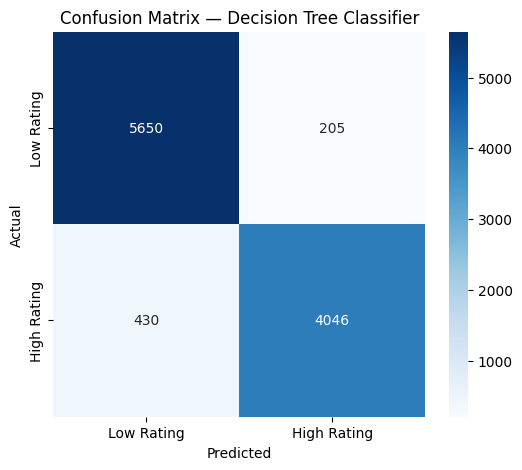

In [45]:
# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_clf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Low Rating', 'High Rating'],
    yticklabels=['Low Rating', 'High Rating']
)
plt.title('Confusion Matrix — Decision Tree Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [46]:
print("Classification Report:")
print(classification_report(
    y_test_c, y_pred_clf,
    target_names=['Low Rating', 'High Rating'],
    zero_division=0
))

Classification Report:
              precision    recall  f1-score   support

  Low Rating       0.93      0.96      0.95      5855
 High Rating       0.95      0.90      0.93      4476

    accuracy                           0.94     10331
   macro avg       0.94      0.93      0.94     10331
weighted avg       0.94      0.94      0.94     10331



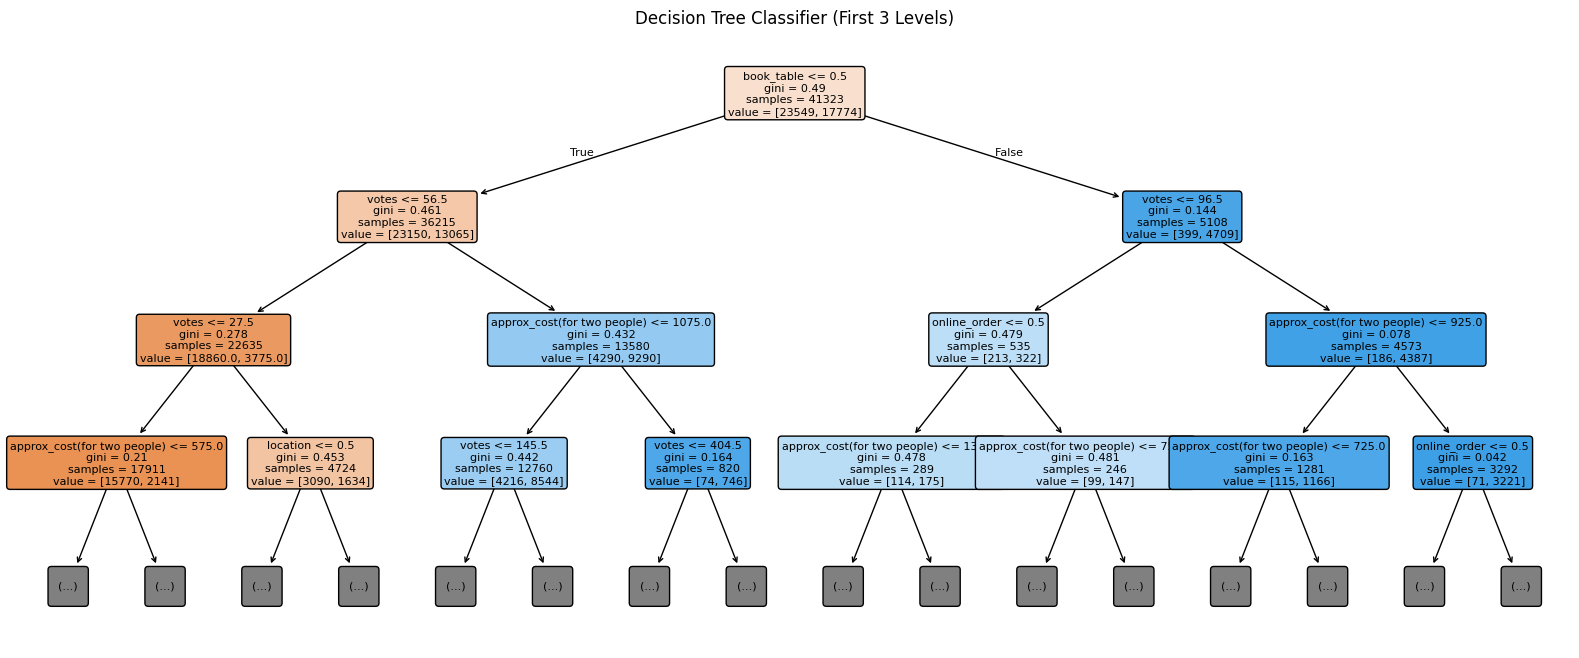

In [47]:
# Visualize Decision Tree Classifier
plt.figure(figsize=(20, 8))
plot_tree(
    best_dt_clf,
    feature_names=X_train_c.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title("Decision Tree Classifier (First 3 Levels)")
plt.show()

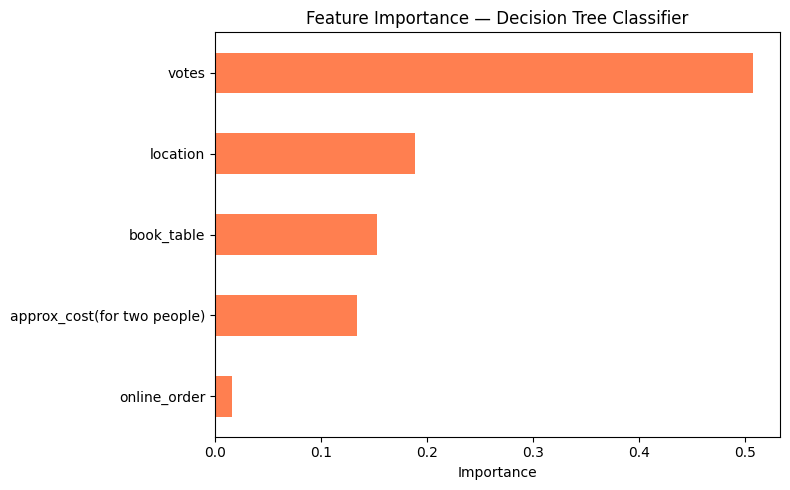

In [48]:
# Feature Importance — Classifier
importances_clf = pd.Series(best_dt_clf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances_clf.plot(kind='barh', color='coral')
plt.title('Feature Importance — Decision Tree Classifier')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [49]:
# For classification (using F1 weighted)
cv_scores_clf = cross_val_score(best_dt_clf, X_train_c, y_train_c, cv=5, scoring='f1_weighted')
print(f"Cross-Validation F1: {cv_scores_clf.mean():.4f} (+/- {cv_scores_clf.std():.4f})")

Cross-Validation F1: 0.9280 (+/- 0.0016)


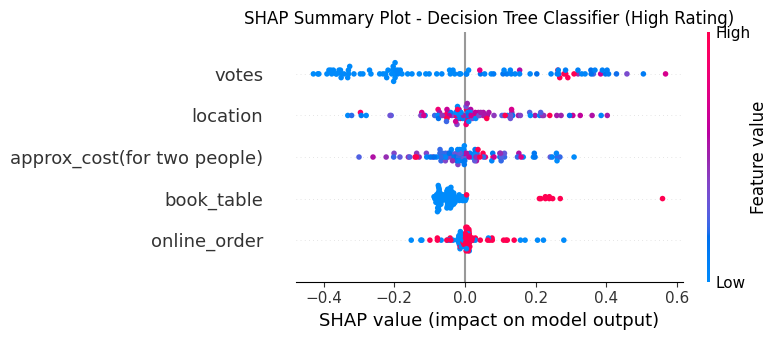

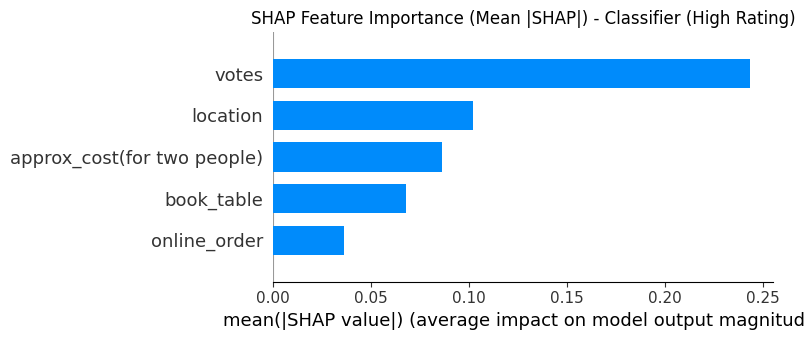

In [50]:
# ----- For Classification -----
X_test_sample_c = X_test_c.sample(n=100, random_state=42)

explainer_clf = shap.TreeExplainer(best_dt_clf)
shap_values_clf = explainer_clf.shap_values(X_test_sample_c)

# Handle both old and new SHAP versions
import numpy as np
if isinstance(shap_values_clf, list):
    # Old SHAP: list of arrays per class
    shap_values_class1 = shap_values_clf[1]
else:
    # New SHAP: 3D array (samples, features, classes)
    shap_values_class1 = shap_values_clf[:, :, 1]

# Summary plot for class 1 (High Rating)
shap.summary_plot(shap_values_class1, X_test_sample_c, feature_names=X_train_c.columns.tolist(), show=False)
plt.title("SHAP Summary Plot - Decision Tree Classifier (High Rating)")
plt.tight_layout()
plt.show()

# Bar plot for class 1
shap.summary_plot(shap_values_class1, X_test_sample_c, feature_names=X_train_c.columns.tolist(), plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|) - Classifier (High Rating)")
plt.tight_layout()
plt.show()

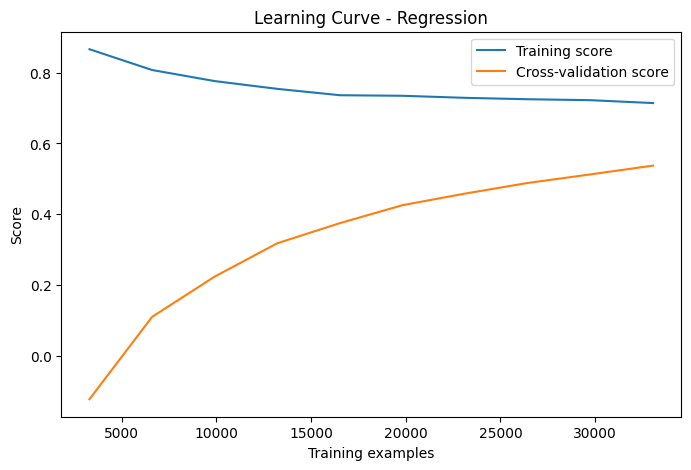

In [51]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_dt_reg, X_train, y_train, cv=5,
    scoring='r2', train_sizes=np.linspace(0.1, 1.0, 10)
)

# Plot
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training score')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('Score')
plt.legend()
plt.title('Learning Curve - Regression')
plt.show()

## Model Saving

In [52]:
# Save trained models using pickle
with open('dt_regressor_with_imputation.pkl', 'wb') as f:
    pickle.dump(best_dt_reg, f)         # ← was dt_reg
print("Decision Tree Regressor saved as 'dt_regressor_with_imputation.pkl'")

with open('dt_classifier_with_imputation.pkl', 'wb') as f:
    pickle.dump(best_dt_clf, f)         # ← was dt_clf
print("Decision Tree Classifier saved as 'dt_classifier_with_imputation.pkl'")

Decision Tree Regressor saved as 'dt_regressor_with_imputation.pkl'
Decision Tree Classifier saved as 'dt_classifier_with_imputation.pkl'


In [53]:
import pickle
import pandas as pd

# Load saved models
loaded_reg = pickle.load(open('dt_regressor_with_imputation.pkl', 'rb'))
loaded_clf = pickle.load(open('dt_classifier_with_imputation.pkl', 'rb'))

# User Input
print("=== Predict Restaurant Rating ===")
online_order  = int(input("Online Order available? (1=Yes, 0=No): "))
book_table    = int(input("Book Table available? (1=Yes, 0=No): "))
votes         = int(input("Number of Votes: "))
location      = int(input("Location (encoded value — check LabelEncoder): "))
approx_cost   = float(input("Approximate Cost for Two People (e.g. 500): "))

# Create input DataFrame — must match training features exactly
new_data = pd.DataFrame({
    'online_order'               : [online_order],
    'book_table'                 : [book_table],
    'votes'                      : [votes],
    'location'                   : [location],
    'approx_cost(for two people)': [approx_cost]   # ← added
})

# Regression Prediction
predicted_rating = best_dt_reg.predict(new_data)[0]    # ← direct, no pkl reload
print(f"\nPredicted Rating     : {predicted_rating:.2f}")

# Classification Prediction
predicted_class = best_dt_clf.predict(new_data)[0]     # ← direct, no pkl reload
rating_label = 'High Rating (>= 3.8)' if predicted_class == 1 else 'Low Rating (< 3.8)'
print(f"Predicted Category   : {rating_label}")

=== Predict Restaurant Rating ===

Predicted Rating     : 3.80
Predicted Category   : High Rating (>= 3.8)
